# <h1><center>Lógica Computacional 2024/2025 - TP4</center></h1>


 **Grupo 6**
 * Cláudia Faria, a105531
 * Patrícia Bastos, a102502

In [ ]:
!pip install pysmt
!pysmt-install --z3

from pysmt.shortcuts import *
from pysmt.typing import *

## **Exercício 1**

No contexto do sistema de travagem ABS (“Anti-Lock Breaking System”), pretende-se construir um autómato híbrido que descreva o sistema e que  possa ser usado para verificar as suas propriedades dinâmicas.

A componente discreta do autómato contém os modos:  `Start`,  `Free`,  `Stopping`, `Blocked`, e `Stopped`. No modo `Free`  não existe qualquer força de travagem; no modo `Stopping` aplica-se a força de travagem alta; no modo `Blocked` as rodas estão bloqueadas em relação ao corpo mas o veículo  desloca-se; no modo `Stopped` o veículo está imobilizado.

A componente contínua  do autómato usa variáveis contínuas V, v para descrever a  `velocidade do corpo`  do veículo em relação ao solo e a `velocidade linear das rodas` também em relação ao solo.  Assume-se que o sistema de travagem exerce uma força de atrito  nos travões proporcional à diferença das duas velocidades.  

**a)** Defina um autómato híbrido que descreva a dinâmica do sistema segundo as notas abaixo indicadas e com os “switchs” por si escolhidos.
Os “switchs” (“jumps”) são uma  componente de projeto deste trabalho; cabe ao aluno definir quais devem ser estas  condições de modo a que o sistema tenha um comportamento desejável: imobilize-se depressa e não “derrape” muito.

Considerando F = c . (V - v) e f = a . P, definimos os estados e as transições da seguinte forma:

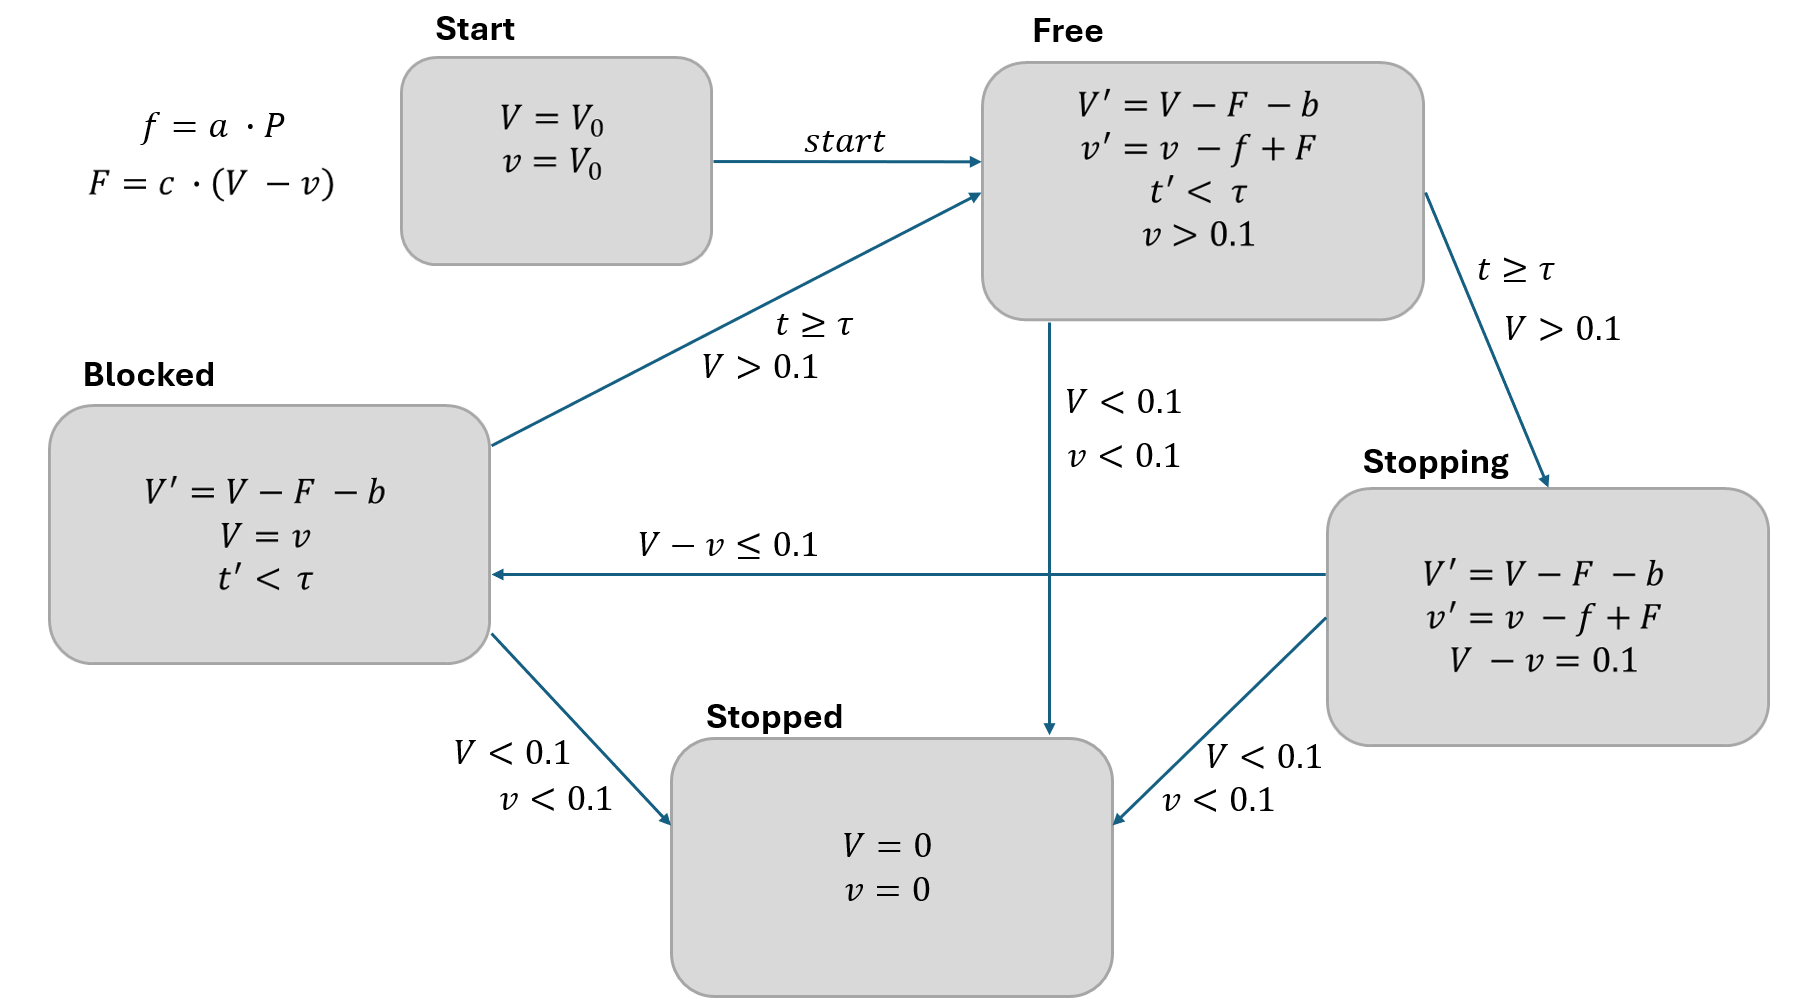

**b)** Modele em lógica temporal linear LT  propriedades que caracterizam o comportamento desejável do sistema. Nomeadamente
1. ”o veículo imobiliza-se completamente em menos de t segundos”
2. “a velocidade V diminui sempre com o tempo”.

Propriedade 1: ◇(tempo ≥ t → m = 4), onde:

◇ é o operador "Eventually" (Finalmente);

→ representa implicação;

A condição verifica-se quando tempo ≥ t, o modo é 4 (Stopped).

Propriedade 2: □(t1 < t2 → V(t1) > V(t2)), onde:

□ é o operador "Always" (Sempre);

Para quaisquer dois instantes de tempo t1 e t2, se t1 < t2, então a velocidade em t1 deve ser maior que a velocidade em t2.

**c)** Construa o FOTS que que descreve a discretização do modelo que definiu em a. e codifique em SMT’s

Primeiro, definem-se os parâmetros físicos e temporais do nosso sistema.

Depois, definem-se as habituais funções declare, init, e gera_traco. Vamos definir os símbolos de modo, tempo, velocidade V e velocidade v.

Em trans, temos de definir todas as transições que o sistema permite, nomeadamente: start, to_stopped (igual para Free, Stopping, Blocked e Stopped), free_to_stopping, stopping_to_blocked, blocked_to_free. Temos ainda de definir as transições entre um só estado que têm limite de tempo através de timed_free, timed_stopping, timed_blocked.

In [ ]:
MODE = {0: "Start", 1: "Free", 2: "Stopping", 3: "Blocked", 4: "Stopped"}

# Definição de Parâmetros
a = 0.8
b = 0.5
P = 1000
tau = 0.15
V_0 = 50.0
c = 0.8

def declare(i):
    s = {}
    s['m'] = Symbol(f'mode_{i}', INT)
    s['t'] = Symbol(f'time_{i}', REAL)
    s['V'] = Symbol(f'velocity_V_{i}', REAL)
    s['v'] = Symbol(f'velocity_v_{i}', REAL)
    return s

def init(s, V_0):
    return And(
        Equals(s['V'], Real(V_0)),
        Equals(s['v'], Real(V_0)),
        Equals(s['t'], Real(0)),
        Equals(s['m'], Int(0))  # Estado inicial "Start"
    )

def trans(s, p, tau):
    modes = [Int(i) for i in range(5)]
    F = Real(c) * (s['V'] - s['v'])
    f = Real(a) * Real(P)
    delta_t = Real(0.0625)  # Incremento fixo de tempo

    # Transição para "Stopped"
    to_stopped = And(
        Or(Equals(s['m'], modes[1]), Equals(s['m'], modes[2]), Equals(s['m'], modes[3]), Equals(s['m'], modes[4])),
        Equals(p['m'], modes[4]),
        LE(s['V'], Real(0.1)),
        LE(s['v'], Real(0.1)),
        Equals(p['V'], Real(0)),
        Equals(p['v'], Real(0)),
        Equals(p['t'], Real(0))
    )

    # Transição de "Start" para "Free"
    start = And(
        Equals(s['m'], modes[0]),
        Equals(p['m'], modes[1]),
        Equals(p['t'], Real(0)),
        Equals(p['V'], s['V']),
        Equals(p['v'], s['v'])
    )

    # Transição de "Free" para "Stopping" - força a transição quando t >= tau
    free_to_stopping = And(
        Equals(s['m'], modes[1]),
        GE(s['t'], Real(tau)),
        GT(s['V'], Real(0.1)),
        Implies(
            And(GE(s['t'], Real(tau)), GT(s['V'], Real(0.1))),
            And(
                Equals(p['m'], modes[2]),
                Equals(p['t'], Real(0)),
                Equals(p['V'], s['V']),
                Equals(p['v'], s['v'])
            )
        )
    )

    # Transição de "Stopping" para "Blocked"
    stopping_to_blocked = And(
        Equals(s['m'], modes[2]),
        LT(Minus(s['V'], s['v']), Real(0.1)),
        Implies(
            LT(Minus(s['V'], s['v']), Real(0.1)),
            And(
                Equals(p['m'], modes[3]),
                Equals(p['t'], Real(0)),
                Equals(p['V'], s['V']),
                Equals(p['v'], s['v'])
            )
        )
    )

    # Transição de "Blocked" para "Free"
    blocked_to_free = And(
        Equals(s['m'], modes[3]),
        GE(s['t'], Real(tau)),
        GT(s['V'], Real(0.1)),
        Implies(
            And(GE(s['t'], Real(tau)), GT(s['V'], Real(0.1))),
            And(
                Equals(p['m'], modes[1]),
                Equals(p['t'], Real(0)),
                Equals(p['V'], s['V']),
                Equals(p['v'], s['v'])
            )
        )
    )

    # Atualizações contínuas
    update_free = And(
        Equals(p['V'], Max(Real(0), Minus(s['V'], Plus(F, Real(b))))),
        Equals(p['v'], Max(Real(0), Minus(s['v'], Minus(f, F))))
    )

    update_stopping = And(
        Equals(p['V'], Max(Real(0), Minus(s['V'], Plus(F, Real(b))))),
        Equals(p['v'], Max(Real(0), Minus(s['v'], Minus(f, F))))
    )

    update_blocked = And(
        Equals(p['V'], Max(Real(0), Minus(s['V'], Plus(f, Real(b))))),
        Equals(p['v'], p['V'])
    )

    # Transições temporizadas com restrições mais fortes
    timed_free = And(
        Equals(s['m'], modes[1]),
        LT(s['t'], Real(tau)),  # Só permite permanecer em Free se t < tau
        Equals(p['m'], modes[1]),
        Equals(p['t'], Plus(s['t'], delta_t)),
        update_free
    )

    timed_stopping = And(
        Equals(s['m'], modes[2]),
        Equals(p['m'], modes[2]),
        Equals(p['t'], Plus(s['t'], delta_t)),
        update_stopping
    )

    timed_blocked = And(
        Equals(s['m'], modes[3]),
        LT(s['t'], Real(tau)),  # Só permite permanecer em Blocked se t < tau
        Equals(p['m'], modes[3]),
        Equals(p['t'], Plus(s['t'], delta_t)),
        update_blocked
    )

    timed = Or(timed_free, timed_stopping, timed_blocked)

    return Or(to_stopped, start, free_to_stopping, stopping_to_blocked, blocked_to_free, timed)

def print_vars(s, solver):
    for var in s:
        if var == 'm':
            val = int(solver.get_py_value(s[var]))  # Converte para int
            print(f"  {var} = {MODE[val]}")
        else:
            print(f"  {var} = {float(solver.get_py_value(s[var]))}")

def gera_traco(declare, init, trans, k, V_0):
    states = [declare(i) for i in range(k)]
    with Solver() as solver:
        solver.add_assertion(init(states[0], V_0))
        for i in range(k-1):
            solver.add_assertion(trans(states[i], states[i+1], tau))

        if solver.solve():
            for i, s in enumerate(states):
                print(f"> State {i}:")
                print_vars(s, solver)
        else:
            print("> Not feasible.")

gera_traco(declare, init, trans, 25, V_0)

> State 0:
  m = Start
  t = 0.0
  V = 50.0
  v = 50.0
> State 1:
  m = Free
  t = 0.0
  V = 50.0
  v = 50.0
> State 2:
  m = Free
  t = 0.0625
  V = 49.5
  v = 0.0
> State 3:
  m = Free
  t = 0.125
  V = 9.399999999999999
  v = 0.0
> State 4:
  m = Free
  t = 0.1875
  V = 1.3799999999999992
  v = 0.0
> State 5:
  m = Stopping
  t = 0.0
  V = 1.3799999999999992
  v = 0.0
> State 6:
  m = Stopping
  t = 0.0625
  V = 0.0
  v = 0.0
> State 7:
  m = Blocked
  t = 0.0
  V = 0.0
  v = 0.0
> State 8:
  m = Blocked
  t = 0.0625
  V = 0.0
  v = 0.0
> State 9:
  m = Blocked
  t = 0.125
  V = 0.0
  v = 0.0
> State 10:
  m = Blocked
  t = 0.1875
  V = 0.0
  v = 0.0
> State 11:
  m = Stopped
  t = 0.0
  V = 0.0
  v = 0.0
> State 12:
  m = Stopped
  t = 0.0
  V = 0.0
  v = 0.0
> State 13:
  m = Stopped
  t = 0.0
  V = 0.0
  v = 0.0
> State 14:
  m = Stopped
  t = 0.0
  V = 0.0
  v = 0.0
> State 15:
  m = Stopped
  t = 0.0
  V = 0.0
  v = 0.0
> State 16:
  m = Stopped
  t = 0.0
  V = 0.0
  v = 0.0
> 

Verificamos que se atingiram os objetivos do trabalho: o sistema imobiliza-se depressa (neste caso, em apenas 11 transições) e derrapa pouco, com intervalo de 0.0625 segundos.

**d)** Codifique a verificação das propriedades temporais que definiu em b.

Primeiro, são criadas as funções imobiliza_em_t e V_diminui_com_t que representam as propriedades. Vamos então usar a função bmc_always definida na ficha 6 para criar funções dela que verifiquem estas propriedades.

In [ ]:
def imobiliza_em_t(s): # "o veículo imobiliza-se completamente em menos de t segundos"
    modes = [Int(i) for i in range(5)]
    t = 10 # Vamos considerar 10 segundos, mas podemos experimentar com o valor que quisermos.
    return Implies(GE(s['t'], Real(t)), Equals(s['m'], modes[4]))

def bmc_imobiliza_em_t(declare,init,trans,inv,V_0,K):
    for K in range(1, K+1): # Para cada passo K:
        solver = Solver() # Cria um novo solver
        states = [declare(i) for i in range(K)] # Gera uma sequência de estados
        solver.add_assertion(init(states[0], V_0)) # Adiciona a condição inicial (com velocidade V_0)

        for i in range(K-1):
            solver.add_assertion(trans(states[i], states[i+1], 2)) # Define as transições entre estados usando tau = 2

        solver.add_assertion(Not(inv(states[K-1]))) # Tenta encontrar um caso onde a propriedade falha

        if solver.solve():
            print(f"A propriedade não é válida para K = {K}.")
            return

    print("A propriedade pode ser válida.")

bmc_imobiliza_em_t(declare,init,trans,imobiliza_em_t,30,40)

A propriedade pode ser válida.


In [ ]:
def V_diminui_com_t(s,p): # "a velocidade V diminui sempre com o tempo"
    return Implies(LT(s['t'], p['t']), GT(s['V'], p['V']))

def bmc_V_diminui_com_t(declare,init,trans,inv,V_0,K):
    for K in range(1, K+1): # Para cada passo K:
        solver = Solver() # Cria um novo solver
        states = [declare(i) for i in range(K)] # Gera uma sequência de estados
        solver.add_assertion(init(states[0], V_0)) # Adiciona a condição inicial (com velocidade V_0)
        prop_violada = [] # Cria uma lista aux que guarda todas as possíveis violações da propriedade

        for i in range(K-1):
            solver.add_assertion(trans(states[i], states[i+1], 2)) # Define as transições entre estados usando tau = 2
            prop_violada.append(Not(inv(states[i], states[i+1]))) # Tenta encontrar um caso onde a propriedade falha, comparando

        solver.add_assertion(Or(prop_violada)) # Verifica se alguma transição viola a propriedade

        if solver.solve():
            print(f"A propriedade não é válida para K = {K}.")
            return

    print("A propriedade pode ser válida.")

bmc_V_diminui_com_t(declare,init,trans,V_diminui_com_t,30,40)

A propriedade não é válida para K = 7.
